<a href="https://colab.research.google.com/github/paulinepiccio/cinema-and-war/blob/main/notebooks/02_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Load raw data from GitHub (raw file URL)

RAW_DATA_URL = "https://raw.githubusercontent.com/paulinepiccio/cinema-and-war/main/data/raw/war_movies_raw.csv"

df = pd.read_csv(RAW_DATA_URL)

print(f"Raw dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Raw dataset loaded: 6308 rows × 14 columns

Columns: ['id', 'title', 'original_title', 'original_language', 'release_date', 'release_year', 'decade', 'overview', 'popularity', 'vote_average', 'vote_count', 'origin_country_code', 'origin_country_name', 'genre_ids']


,id,title,original_title,original_language,release_date,release_year,decade,overview,popularity,vote_average,vote_count,origin_country_code,origin_country_name,genre_ids
0,424,Schindler's List,Schindler's List,en,1993-12-15,1993,1990,The true story of how businessman Oskar Schind...,26.1437,8.568,17405,US,United States,"[18, 36, 10752]"
1,652,Troy,Troy,en,2004-05-13,2004,2000,"In year 1250 B.C. during the late Bronze age, ...",19.4147,7.169,11000,US,United States,"[10752, 28, 36]"
2,1495,Kingdom of Heaven,Kingdom of Heaven,en,2005-05-03,2005,2000,"After his wife dies, a blacksmith named Balian...",16.3479,7.028,4909,US,United States,"[18, 28, 12, 36, 10752]"
3,16869,Inglourious Basterds,Inglourious Basterds,en,2009-08-02,2009,2000,"In Nazi-occupied France during World War II, a...",16.0413,8.217,24102,US,United States,"[18, 53, 10752]"
4,324786,Hacksaw Ridge,Hacksaw Ridge,en,2016-10-07,2016,2010,"WWII American Army Medic Desmond T. Doss, who ...",16.5140,8.200,14800,US,United States,"[18, 36, 10752]"


In [ ]:
# Quick health check
print("Dataset overview:\n")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nNumeric columns summary:")
print(df[['popularity', 'vote_average', 'vote_count', 'release_year']].describe())

Dataset overview:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6308 entries, 0 to 6307
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6308 non-null   int64  
 1   title                6308 non-null   object 
 2   original_title       6308 non-null   object 
 3   original_language    6308 non-null   object 
 4   release_date         6308 non-null   object 
 5   release_year         6308 non-null   int64  
 6   decade               6308 non-null   int64  
 7   overview             5909 non-null   object 
 8   popularity           6308 non-null   float64
 9   vote_average         6308 non-null   float64
 10  vote_count           6308 non-null   int64  
 11  origin_country_code  6308 non-null   object 
 12  origin_country_name  6308 non-null   object 
 13  genre_ids            6308 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 690.1+ KB
None

Miss

Median vote_count by country:

                     median   mean  count
origin_country_name                      
France                  2.0   42.8    823
Germany                 3.5  104.5    362
Japan                   2.0   32.0    455
Russia                  2.0   32.1    285
United Kingdom          8.0  157.2    878
United States           3.0  177.7   3505

Movies kept per country at different thresholds:

Country              Total      >=5      >=10     >=20    
------------------------------------------------------------
United States        3505       1486     1127     830     
France               823        314      228      172     
United Kingdom       878        519      422      321     
Germany              362        160      103      80      
Russia               285        122      92       59      
Japan                455        154      108      63      


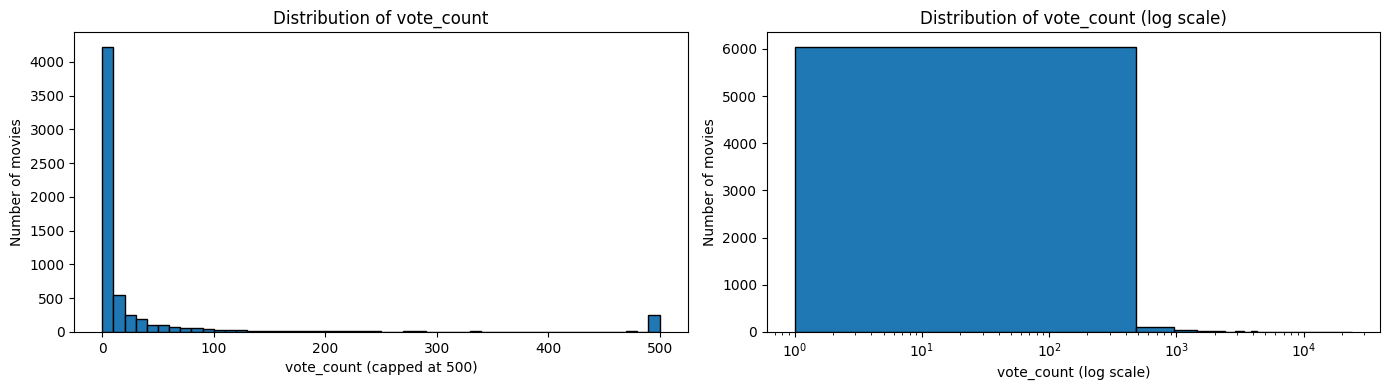


Conclusion: a uniform threshold would heavily penalize non-anglophone cinemas.
    We will use an adaptive threshold per country.


In [ ]:
# Analyze vote_count distribution to inform our filtering strategy

print("Median vote_count by country:\n")
print(df.groupby('origin_country_name')['vote_count'].agg(['median', 'mean', 'count']).round(1))

print("\nMovies kept per country at different thresholds:\n")
print(f"{'Country':<20} {'Total':<10} {'>=5':<8} {'>=10':<8} {'>=20':<8}")
print("-" * 60)
for country in df['origin_country_name'].unique():
    subset = df[df['origin_country_name'] == country]
    total = len(subset)
    over_5 = (subset['vote_count'] >= 5).sum()
    over_10 = (subset['vote_count'] >= 10).sum()
    over_20 = (subset['vote_count'] >= 20).sum()
    print(f"{country:<20} {total:<10} {over_5:<8} {over_10:<8} {over_20:<8}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['vote_count'].clip(upper=500), bins=50, edgecolor='black')
axes[0].set_xlabel('vote_count (capped at 500)')
axes[0].set_ylabel('Number of movies')
axes[0].set_title('Distribution of vote_count')

axes[1].hist(df['vote_count'].clip(lower=1), bins=50, edgecolor='black')
axes[1].set_xscale('log')
axes[1].set_xlabel('vote_count (log scale)')
axes[1].set_ylabel('Number of movies')
axes[1].set_title('Distribution of vote_count (log scale)')

plt.tight_layout()
plt.show()

print("\nConclusion: a uniform threshold would heavily penalize non-anglophone cinemas.")
print("    We will use an adaptive threshold per country.")

In [ ]:
# Movies without overview can't be matched to a conflict later

before = len(df)
df = df.dropna(subset=['overview'])
after = len(df)

print(f"Removed {before - after} movies without overview")
print(f"Remaining: {after} movies")

Removed 399 movies without overview
Remaining: 5909 movies


In [ ]:
# Some films appear multiple times (for example a UK-French co-production appears once with origin_country=GB, once with FR).
# Strategy: keep one row per film, but list all origin countries.

duplicate_count = df.duplicated(subset='id').sum()
print(f"Found {duplicate_count} duplicate films (same TMDB id, different origin country)")

df_grouped = df.groupby('id').agg({
    'title': 'first',
    'original_title': 'first',
    'original_language': 'first',
    'release_date': 'first',
    'release_year': 'first',
    'decade': 'first',
    'overview': 'first',
    'popularity': 'first',
    'vote_average': 'first',
    'vote_count': 'first',
    'origin_country_code': lambda x: ','.join(sorted(set(x))),
    'origin_country_name': lambda x: ','.join(sorted(set(x))),
    'genre_ids': 'first'
}).reset_index()

# Create a 'primary_country' column (first country alphabetically)
# This is used for analysis grouping; the full list is preserved
df_grouped['primary_country'] = df_grouped['origin_country_code'].str.split(',').str[0]

print(f"After deduplication: {df_grouped.shape[0]} unique films")
print(f"\n Films with multi-country co-productions:")
multi_country = df_grouped[df_grouped['origin_country_code'].str.contains(',')]
print(f"   {len(multi_country)} films are co-productions")

Found 456 duplicate films (same TMDB id, different origin country)
After deduplication: 5453 unique films

 Films with multi-country co-productions:
   437 films are co-productions


In [ ]:
# Adaptive filtering: minimum 5 votes AND top 60% per country
# Rationale:
# - The absolute minimum (5 votes) removes ghost entries and abandoned productions
# - The country-level threshold (top 60%) ensures fair representation across cinema industries, regardless of TMDB's anglo-centric audience bias

MIN_VOTES_ABSOLUTE = 5
QUANTILE_THRESHOLD = 0.40  # keep movies above this percentile within their country

before = len(df_grouped)

# Compute per-country threshold and apply both filters
df_grouped['country_threshold'] = df_grouped.groupby('primary_country')['vote_count'].transform(
    lambda x: x.quantile(QUANTILE_THRESHOLD)
)

df_filtered = df_grouped[
    (df_grouped['vote_count'] >= MIN_VOTES_ABSOLUTE) &
    (df_grouped['vote_count'] >= df_grouped['country_threshold'])
].copy()

# Drop the temporary threshold column
df_filtered = df_filtered.drop(columns=['country_threshold'])

after = len(df_filtered)

print(f"Removed {before - after} movies")
print(f"   Filters applied:")
print(f"   - vote_count >= {MIN_VOTES_ABSOLUTE} (absolute minimum)")
print(f"   - vote_count >= {int(QUANTILE_THRESHOLD*100)}th percentile within country")
print(f"Remaining: {after} movies\n")

print("Movies kept per country after adaptive filtering:")
print(df_filtered['primary_country'].value_counts())

print("\n Country share of final dataset:")
shares = (df_filtered['primary_country'].value_counts(normalize=True) * 100).round(1)
print(shares.astype(str) + '%')

Removed 3006 movies
   Filters applied:
   - vote_count >= 5 (absolute minimum)
   - vote_count >= 40th percentile within country
Remaining: 2447 movies

Movies kept per country after adaptive filtering:
primary_country
US    1241
GB     489
FR     295
DE     157
JP     152
RU     113
Name: count, dtype: int64

 Country share of final dataset:
primary_country
US    50.7%
GB    20.0%
FR    12.1%
DE     6.4%
JP     6.2%
RU     4.6%
Name: proportion, dtype: object


In [ ]:
before = len(df_filtered)
df_filtered = df_filtered[df_filtered['release_year'] >= 1945].copy()
after = len(df_filtered)

print(f"🗑️ Removed {before - after} movies released before 1945")
print(f"📦 Remaining: {after} movies")

🗑️ Removed 310 movies released before 1945
📦 Remaining: 2137 movies


Cleaned dataset: 2137 movies

Movies per primary origin country:
primary_country
US    1009
GB     433
FR     289
JP     148
DE     145
RU     113
Name: count, dtype: int64

Movies per decade:
decade
1940     85
1950    291
1960    253
1970    138
1980    202
1990    179
2000    320
2010    449
2020    220
Name: count, dtype: int64


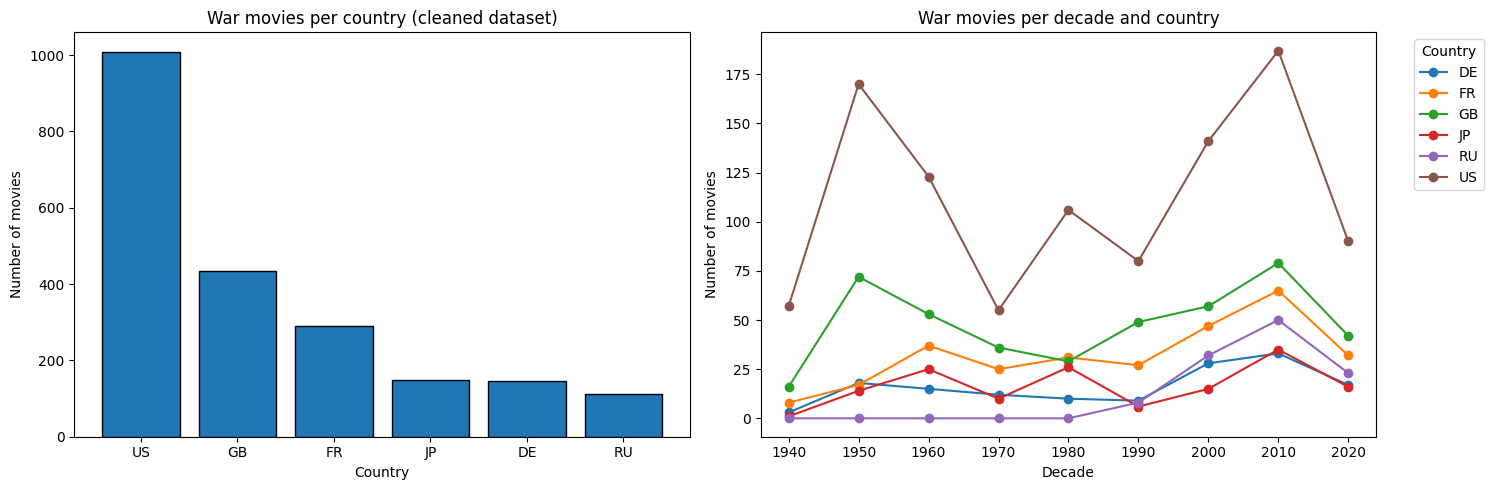

In [ ]:
# Final dataset summary
print(f"Cleaned dataset: {df_filtered.shape[0]} movies\n")

print("Movies per primary origin country:")
print(df_filtered['primary_country'].value_counts())

print("\nMovies per decade:")
print(df_filtered['decade'].value_counts().sort_index())

# Visualization: movies per country and per decade
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: bar chart by country
country_counts = df_filtered['primary_country'].value_counts()
axes[0].bar(country_counts.index, country_counts.values, edgecolor='black')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Number of movies')
axes[0].set_title('War movies per country (cleaned dataset)')

# Right: line chart by decade
decade_counts = df_filtered.groupby(['decade', 'primary_country']).size().unstack(fill_value=0)
decade_counts.plot(ax=axes[1], marker='o')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Number of movies')
axes[1].set_title('War movies per decade and country')
axes[1].legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# Save cleaned dataset locally
output_path = 'war_movies_cleaned.csv'
df_filtered.to_csv(output_path, index=False, encoding='utf-8')

print(f"Saved: {output_path}")
print(f"Final size: {df_filtered.shape[0]} movies, {df_filtered.shape[1]} columns")
print(f"\nFinal columns: {df_filtered.columns.tolist()}")

Saved: war_movies_cleaned.csv
Final size: 2137 movies, 15 columns

Final columns: ['id', 'title', 'original_title', 'original_language', 'release_date', 'release_year', 'decade', 'overview', 'popularity', 'vote_average', 'vote_count', 'origin_country_code', 'origin_country_name', 'genre_ids', 'primary_country']


In [ ]:
from google.colab import files
files.download('war_movies_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>